# PDF → Structured JSON (self-contained)

All code lives in this notebook. Uses **LangChain + Gemini** (one vision call per page).

1. Set `PDF_PATH` and `N_PAGES` in the next cell.
2. Run all cells in order.

Requires `.env` in project root with `GEMINI_API_KEY`. Optional: `GEMINI_MODEL` (default `gemini-3-flash-preview`), `GEMINI_MODEL_RETRY` (`gemini-3.1-pro-preview`), `MAX_EXTRACTION_RETRIES` (3).

**Run order:** Restart kernel → run all cells. Re-run after code changes (stale outputs may show old errors).

In [15]:
import os
from pathlib import Path

import google.generativeai as genai
from dotenv import load_dotenv

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

load_dotenv(ROOT / ".env")

api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise RuntimeError(f"Set GEMINI_API_KEY in {ROOT / '.env'}")

genai.configure(api_key=api_key)

print("Available models:")
for model in genai.list_models():
    print(f"- {model.name}: {model.display_name}")

print("\nModels supporting content generation:")
for model in genai.list_models():
    if "generateContent" in model.supported_generation_methods:
        print(f"- {model.name}")

Available models:
- models/gemini-2.5-flash: Gemini 2.5 Flash
- models/gemini-2.5-pro: Gemini 2.5 Pro
- models/gemini-2.0-flash: Gemini 2.0 Flash
- models/gemini-2.0-flash-001: Gemini 2.0 Flash 001
- models/gemini-2.0-flash-lite-001: Gemini 2.0 Flash-Lite 001
- models/gemini-2.0-flash-lite: Gemini 2.0 Flash-Lite
- models/gemini-2.5-flash-preview-tts: Gemini 2.5 Flash Preview TTS
- models/gemini-2.5-pro-preview-tts: Gemini 2.5 Pro Preview TTS
- models/gemma-4-26b-a4b-it: Gemma 4 26B A4B IT
- models/gemma-4-31b-it: Gemma 4 31B IT
- models/gemini-flash-latest: Gemini Flash Latest
- models/gemini-flash-lite-latest: Gemini Flash-Lite Latest
- models/gemini-pro-latest: Gemini Pro Latest
- models/gemini-2.5-flash-lite: Gemini 2.5 Flash-Lite
- models/gemini-2.5-flash-image: Nano Banana
- models/gemini-3-pro-preview: Gemini 3 Pro Preview
- models/gemini-3-flash-preview: Gemini 3 Flash Preview
- models/gemini-3.1-pro-preview: Gemini 3.1 Pro Preview
- models/gemini-3.1-pro-preview-customtools: Ge

In [21]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

if not os.getenv("GEMINI_API_KEY"):
    raise RuntimeError(f"Set GEMINI_API_KEY in {ROOT / '.env'}")

GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-3-flash-preview")
GEMINI_MODEL_RETRY = os.getenv("GEMINI_MODEL_RETRY", "gemini-3.1-pro-preview")
MAX_EXTRACTION_RETRIES = int(os.getenv("MAX_EXTRACTION_RETRIES", "3"))

# --- Configuration ---
PDF_PATH = ROOT / "data" / "input" / "Input-Example.pdf"
N_PAGES = 30
DOCUMENT_ID = None
DPI = 150
EMBED_IMAGE_CROPS = False
OUTPUT_PATH = ROOT / "data" / "outputs" / "structured_document.json"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Model (primary): {GEMINI_MODEL}")
print(f"Model (retry):   {GEMINI_MODEL_RETRY}")
print(f"Max retries:     {MAX_EXTRACTION_RETRIES}")
print(f"PDF: {PDF_PATH} (exists={PDF_PATH.exists()})")

ROOT: /home/dev/Projects/kwikee/medrecs_2
Model (primary): gemini-2.5-flash
Model (retry):   gemini-3.1-pro-preview
Max retries:     3
PDF: /home/dev/Projects/kwikee/medrecs_2/data/input/Input-Example.pdf (exists=True)


In [22]:
# --- Imports ---
import base64
import io
import json
import re
import time
from enum import Enum
from typing import Any, List, Optional, Tuple

import fitz
import pandas as pd
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from PIL import Image
from pydantic import BaseModel, Field, field_validator

load_dotenv(ROOT / ".env")


# --- Pydantic schemas ---
class ElementType(str, Enum):
    HEADER = "HEADER"
    BARCODE = "BARCODE"
    TEXT = "TEXT"
    CHECKBOX = "CHECKBOX"
    TABLE = "TABLE"
    IMAGE = "IMAGE"
    SIGNATURE = "SIGNATURE"
    FOOTER = "FOOTER"


def _clamp_box(box: List[float]) -> List[float]:
    x0, y0, x1, y1 = [max(0.0, min(1.0, float(v))) for v in box[:4]]
    if x0 >= x1:
        x1 = min(1.0, x0 + 0.01)
    if y0 >= y1:
        y1 = min(1.0, y0 + 0.01)
    return [x0, y0, x1, y1]


class DocumentElement(BaseModel):
    element_type: ElementType
    page_number: int
    content: str
    bounding_boxes: List[List[float]] = Field(default_factory=list)

    @field_validator("bounding_boxes", mode="before")
    @classmethod
    def normalize_boxes(cls, boxes: Any) -> List[List[float]]:
        if not boxes:
            return []
        out = []
        for box in boxes:
            if isinstance(box, (list, tuple)) and len(box) >= 4:
                out.append(_clamp_box([float(v) for v in box[:4]]))
        return out

    @field_validator("element_type", mode="before")
    @classmethod
    def coerce_element_type(cls, v: Any) -> Any:
        if isinstance(v, ElementType):
            return v
        s = str(v or "TEXT").upper().replace(" ", "_").replace("-", "_")
        if s in ElementType.__members__:
            return s
        return ElementType.TEXT.value


class PageElementsResult(BaseModel):
    elements: List[DocumentElement] = Field(default_factory=list)


class StructuredDocument(BaseModel):
    document_id: str
    total_pages: int
    is_scanned_ocr: bool
    elements: List[DocumentElement] = Field(default_factory=list)


print("Schemas loaded.")

Schemas loaded.


In [23]:
# --- Prompts (paragraph / section granularity) ---
PAGE_EXTRACT_SYSTEM = """You are a medical document layout extraction agent.
Extract SEMANTIC layout blocks — NOT one element per printed line.

## Element types
HEADER, BARCODE, TEXT, CHECKBOX, TABLE, IMAGE, SIGNATURE, FOOTER

## Granularity rules (critical)
1. TEXT = one element per PARAGRAPH or continuous body block.
   - Merge all wrapped lines of the same paragraph into a single "content" string (use spaces between lines).
   - One bounding_boxes entry: [[x0,y0,x1,y1]] enclosing the FULL paragraph (union of all its lines).
   - Do NOT emit separate elements for each visual line of the same paragraph.

2. HEADER = section titles or standalone labels (e.g. "Presenting Problem:", report title lines).
   - Short title lines may each be HEADER; do not merge unrelated headers together.

3. TABLE = one element per table (markdown pipe table in content, one enclosing box).

4. CHECKBOX, IMAGE, SIGNATURE, BARCODE, FOOTER = one element per distinct widget/region.

5. Form/meta lines: keep logical units together (e.g. "Name: X DOB: Y" as one TEXT if on same block).

## Bounding boxes
- Normalized [x0, y0, x1, y1], values 0.0–1.0, top-left origin.
- Must wrap the entire semantic block, not a single text line.

## Output
- Top-to-bottom order. page_number must match the user message.
- Return ONLY valid JSON:
  {"elements": [{"element_type": "TEXT", "page_number": 1, "content": "...", "bounding_boxes": [[0.1, 0.2, 0.9, 0.5]]}]}
- Use "content" not "text". Never use pixel coordinates.
- Escape double quotes inside content as \". Use \\n for line breaks, not raw newlines in strings.
- Valid JSON only: no trailing commas, no comments.
- Transcribe faithfully. Do not invent text."""

PAGE_EXTRACT_USER = """page_number: {page_number}
Extract semantic layout blocks from this page. Remember: one TEXT element per paragraph, not per line."""


def slug_document_id(pdf_path: Path) -> str:
    stem = re.sub(r"[^a-zA-Z0-9]+", "_", pdf_path.stem).strip("_").lower()
    return f"doc_{stem}" if stem else "doc_unknown"


def render_page_png(pdf_path: Path, page_index: int, dpi: int = 150) -> bytes:
    doc = fitz.open(pdf_path)
    try:
        page = doc[page_index]
        matrix = fitz.Matrix(dpi / 72, dpi / 72)
        return page.get_pixmap(matrix=matrix, alpha=False).tobytes("png")
    finally:
        doc.close()


def detect_scanned_ocr(pdf_path: Path, sample_pages: int = 3, threshold: float = 0.002) -> bool:
    doc = fitz.open(pdf_path)
    try:
        n = min(sample_pages, len(doc))
        if n == 0:
            return True
        densities = []
        for i in range(n):
            page = doc[i]
            text = (page.get_text() or "").strip()
            area = max(page.rect.width * page.rect.height, 1.0)
            densities.append(len(text) / area)
        return sum(densities) / len(densities) < threshold
    finally:
        doc.close()


def get_llm(model_name: str | None = None) -> ChatGoogleGenerativeAI:
    return ChatGoogleGenerativeAI(
        model=model_name or GEMINI_MODEL,
        google_api_key=os.environ["GEMINI_API_KEY"],
        temperature=0.1,
        max_output_tokens=8192,
        model_kwargs={"response_mime_type": "application/json"},
    )


def _usage_from_message(msg: Any) -> dict:
    meta = getattr(msg, "response_metadata", None) or {}
    u = meta.get("usage_metadata") or meta.get("token_usage") or {}
    return {
        "prompt_tokens": u.get("prompt_token_count") or u.get("input_tokens"),
        "candidates_tokens": u.get("candidates_token_count") or u.get("output_tokens"),
        "total_tokens": u.get("total_token_count") or u.get("total_tokens"),
    }


def _parse_json_text(text: str) -> dict:
    text = (text or "").strip()
    if not text:
        raise ValueError("Empty model response")
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text).strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    start = text.find("{")
    if start >= 0:
        depth = 0
        for i, ch in enumerate(text[start:], start):
            if ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    chunk = text[start : i + 1]
                    try:
                        return json.loads(chunk)
                    except json.JSONDecodeError:
                        try:
                            from json_repair import repair_json
                            return json.loads(repair_json(chunk))
                        except Exception:
                            pass
                    break
    try:
        from json_repair import repair_json
        return json.loads(repair_json(text))
    except Exception:
        pass
    raise ValueError(
        f"Could not parse JSON (len={len(text)}). "
        f"head={text[:300]!r} ... tail={text[-300:]!r}"
    )


def _normalize_bbox(box: List[float], img_w: int, img_h: int) -> List[float]:
    x0, y0, x1, y1 = [float(v) for v in box[:4]]
    if max(abs(x0), abs(y0), abs(x1), abs(y1)) > 1.0:
        x0, x1 = x0 / img_w, x1 / img_w
        y0, y1 = y0 / img_h, y1 / img_h
    return _clamp_box([x0, y0, x1, y1])


def _coerce_boxes(raw: Any, img_w: int, img_h: int) -> List[List[float]]:
    if raw is None:
        return []
    if isinstance(raw, dict):
        if all(k in raw for k in ("x", "y", "width", "height")):
            x, y, w, h = float(raw["x"]), float(raw["y"]), float(raw["width"]), float(raw["height"])
            return [_normalize_bbox([x, y, x + w, y + h], img_w, img_h)]
        if all(k in raw for k in ("x0", "y0", "x1", "y1")):
            return [_normalize_bbox([raw["x0"], raw["y0"], raw["x1"], raw["y1"]], img_w, img_h)]
    if isinstance(raw, (list, tuple)) and len(raw) == 4:
        if all(isinstance(v, (int, float)) for v in raw):
            return [_normalize_bbox(list(raw), img_w, img_h)]
    if isinstance(raw, (list, tuple)):
        out = []
        for item in raw:
            if isinstance(item, (list, tuple)) and len(item) >= 4:
                out.append(_normalize_bbox(list(item[:4]), img_w, img_h))
        return out
    return []


def _infer_element_type(content: str, item: dict) -> str:
    et = str(item.get("element_type") or item.get("type") or "").upper()
    if et in ElementType.__members__:
        return et
    c = content.lower()
    if "checkbox" in c or c.startswith("state:"):
        return ElementType.CHECKBOX.value
    if "|" in content and content.count("|") >= 2:
        return ElementType.TABLE.value
    if "presence_detected" in c or "signature" in c:
        return ElementType.SIGNATURE.value
    if item.get("barcode") or "mrn" in c[:20]:
        return ElementType.BARCODE.value
    if "page " in c and " of " in c and len(content) < 40:
        return ElementType.FOOTER.value
    return ElementType.TEXT.value


def _normalize_raw_element(item: dict, page_number: int, img_w: int, img_h: int) -> dict:
    content = item.get("content") or item.get("text") or item.get("value") or item.get("label") or ""
    if isinstance(content, (dict, list)):
        content = json.dumps(content)
    content = str(content).strip()
    if not content:
        content = str(item.get("description") or item.get("body") or "").strip()

    et = _infer_element_type(content, item)
    boxes = _coerce_boxes(
        item.get("bounding_boxes") or item.get("bbox") or item.get("box") or item.get("bounds"),
        img_w,
        img_h,
    )
    return {
        "element_type": et,
        "page_number": int(item.get("page_number") or item.get("page") or page_number),
        "content": content or "(empty)",
        "bounding_boxes": boxes,
    }


def normalize_page_response(data: Any, page_number: int, img_w: int, img_h: int) -> dict:
    if isinstance(data, list):
        items = data
    elif isinstance(data, dict):
        items = data.get("elements") or data.get("items") or data.get("blocks") or data.get("regions") or []
    else:
        items = []
    elements = []
    for item in items:
        if not isinstance(item, dict):
            continue
        try:
            elements.append(_normalize_raw_element(item, page_number, img_w, img_h))
        except Exception as exc:
            print(f"  warning: skipped one element: {exc}")
    return {"elements": elements}


# Fallback if model still returns line-level TEXT
MERGE_TEXT_TYPES = {ElementType.TEXT.value, "TEXT"}
X_ALIGN_TOLERANCE = 0.05
Y_LINE_GAP_MAX = 0.028


def _box_y0(box: List[float]) -> float:
    return box[0][1] if box else 0.0


def _box_union(a: List[float], b: List[float]) -> List[float]:
    return _clamp_box([min(a[0], b[0]), min(a[1], b[1]), max(a[2], b[2]), max(a[3], b[3])])


def _should_merge_text(prev: dict, curr: dict) -> bool:
    if prev.get("element_type") not in MERGE_TEXT_TYPES:
        return False
    if curr.get("element_type") not in MERGE_TEXT_TYPES:
        return False
    pb, cb = prev.get("bounding_boxes") or [], curr.get("bounding_boxes") or []
    if not pb or not cb:
        return False
    p, c = pb[0], cb[0]
    if abs(p[0] - c[0]) > X_ALIGN_TOLERANCE:
        return False
    if abs(p[2] - c[2]) > X_ALIGN_TOLERANCE:
        return False
    gap = c[1] - p[3]
    return -0.01 <= gap <= Y_LINE_GAP_MAX


def merge_line_level_text(elements: List[dict]) -> List[dict]:
    if not elements:
        return []
    sorted_els = sorted(
        elements,
        key=lambda e: (_box_y0(e.get("bounding_boxes") or [[0, 0, 0, 0]]), e.get("element_type", "")),
    )
    merged: List[dict] = []
    for el in sorted_els:
        if merged and _should_merge_text(merged[-1], el):
            prev = merged[-1]
            prev["content"] = (prev["content"].rstrip() + " " + el["content"].lstrip()).strip()
            prev["bounding_boxes"] = [_box_union(prev["bounding_boxes"][0], el["bounding_boxes"][0])]
        else:
            merged.append(dict(el))
    return merged


def merge_page_response_elements(normalized: dict) -> dict:
    elements = normalized.get("elements") or []
    return {"elements": merge_line_level_text(elements)}


def _invoke_page_extraction(
    png_bytes: bytes,
    page_number: int,
    model_name: str,
) -> Tuple[PageElementsResult, dict]:
    llm = get_llm(model_name)
    b64 = base64.standard_b64encode(png_bytes).decode("ascii")
    user = PAGE_EXTRACT_USER.format(page_number=page_number)
    messages = [
        SystemMessage(content=PAGE_EXTRACT_SYSTEM),
        HumanMessage(
            content=[
                {"type": "text", "text": user},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
            ]
        ),
    ]
    response = llm.invoke(messages)
    raw = response.content
    if isinstance(raw, list):
        raw = "".join(
            block.get("text", "") if isinstance(block, dict) else str(block)
            for block in raw
        )
    img = Image.open(io.BytesIO(png_bytes))
    img_w, img_h = img.size
    data = _parse_json_text(str(raw))
    normalized = normalize_page_response(data, page_number, img_w, img_h)
    raw_count = len(normalized.get("elements", []))
    merged = merge_page_response_elements(normalized)
    if len(merged.get("elements", [])) < raw_count:
        print(f"    merged {raw_count} → {len(merged['elements'])} elements (line collapse)")
    result = PageElementsResult.model_validate(merged)
    usage = _usage_from_message(response)
    usage["model"] = model_name
    return result, usage


def extract_page_elements(
    png_bytes: bytes,
    page_number: int,
    max_retries: int | None = None,
) -> Tuple[PageElementsResult, dict]:
    """Vision extraction: gemini-3-flash-preview first, gemini-3.1-pro-preview on retry."""
    max_retries = max_retries if max_retries is not None else MAX_EXTRACTION_RETRIES
    models = [GEMINI_MODEL] + [GEMINI_MODEL_RETRY] * max(0, max_retries - 1)
    last_err: Exception | None = None

    for attempt, model_name in enumerate(models, start=1):
        try:
            if attempt > 1:
                print(f"    retry {attempt}/{len(models)} with {model_name}")
            result, usage = _invoke_page_extraction(png_bytes, page_number, model_name)
            if attempt > 1:
                print(f"    succeeded on attempt {attempt} ({model_name})")
            return result, usage
        except Exception as e:
            last_err = e
            print(f"    attempt {attempt} ({model_name}) failed: {type(e).__name__}: {e}")
            if attempt < len(models):
                time.sleep(2 * attempt)

    raise RuntimeError(
        f"Page {page_number} failed after {len(models)} attempt(s)"
    ) from last_err


def crop_element_base64(png_bytes: bytes, box: List[float], max_width: int = 512) -> str:
    img = Image.open(io.BytesIO(png_bytes))
    w, h = img.size
    x0, y0, x1, y1 = _clamp_box(box)
    cropped = img.crop((int(x0 * w), int(y0 * h), int(x1 * w), int(y1 * h)))
    if cropped.width > max_width:
        ratio = max_width / cropped.width
        cropped = cropped.resize(
            (max_width, max(1, int(cropped.height * ratio))), Image.Resampling.LANCZOS
        )
    buf = io.BytesIO()
    cropped.save(buf, format="JPEG", quality=85)
    return f"data:image/jpeg;base64,{base64.b64encode(buf.getvalue()).decode('ascii')}"


def enrich_image_elements(
    elements: List[DocumentElement], png_bytes: bytes
) -> List[DocumentElement]:
    out = []
    for el in elements:
        if el.element_type == ElementType.IMAGE and el.bounding_boxes:
            try:
                el = el.model_copy(
                    update={"content": crop_element_base64(png_bytes, el.bounding_boxes[0])}
                )
            except Exception:
                pass
        out.append(el)
    return out


def extract_structured_document(
    pdf_path: Path,
    n_pages: int,
    document_id: Optional[str] = None,
    dpi: int = 150,
    embed_image_crops: bool = False,
) -> Tuple[StructuredDocument, List[dict]]:
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    doc = fitz.open(pdf_path)
    total = len(doc)
    doc.close()

    n = min(n_pages, total)
    doc_id = document_id or slug_document_id(pdf_path)
    is_scanned = detect_scanned_ocr(pdf_path)

    all_elements: List[DocumentElement] = []
    usage_log: List[dict] = []

    for i in range(n):
        page_number = i + 1
        print(f"Processing page {page_number}/{n}...")
        png = render_page_png(pdf_path, i, dpi=dpi)
        page_result, usage = extract_page_elements(png, page_number)
        elements = page_result.elements
        if embed_image_crops:
            elements = enrich_image_elements(elements, png)
        all_elements.extend(elements)
        usage_log.append({"page": page_number, "elements": len(elements), **usage})
        print(f"  → {len(elements)} elements, tokens={usage}")

    return (
        StructuredDocument(
            document_id=doc_id,
            total_pages=n,
            is_scanned_ocr=is_scanned,
            elements=all_elements,
        ),
        usage_log,
    )


print("Functions ready.")

Functions ready.


In [24]:
if not PDF_PATH.exists():
    raise FileNotFoundError(f"Put your PDF at: {PDF_PATH}")

doc = fitz.open(PDF_PATH)
print(f"PDF pages in file: {len(doc)}")
print(f"Will extract first: {min(N_PAGES, len(doc))} pages")
doc.close()

PDF pages in file: 1463
Will extract first: 30 pages


In [25]:
structured, usage_log = extract_structured_document(
    pdf_path=PDF_PATH,
    n_pages=N_PAGES,
    document_id=DOCUMENT_ID,
    dpi=DPI,
    embed_image_crops=EMBED_IMAGE_CROPS,
)

print(f"\ndocument_id: {structured.document_id}")
print(f"total_pages: {structured.total_pages}")
print(f"is_scanned_ocr: {structured.is_scanned_ocr}")
print(f"total elements: {len(structured.elements)}")

Processing page 1/30...


/tmp/ipykernel_1694061/1746857490.py:279: UserWarning: Parameters {'response_mime_type'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  llm = get_llm(model_name)


    merged 10 → 6 elements (line collapse)
  → 6 elements, tokens={'prompt_tokens': None, 'candidates_tokens': None, 'total_tokens': None, 'model': 'gemini-2.5-flash'}
Processing page 2/30...
    merged 9 → 8 elements (line collapse)
  → 8 elements, tokens={'prompt_tokens': None, 'candidates_tokens': None, 'total_tokens': None, 'model': 'gemini-2.5-flash'}
Processing page 3/30...
    merged 14 → 11 elements (line collapse)
  → 11 elements, tokens={'prompt_tokens': None, 'candidates_tokens': None, 'total_tokens': None, 'model': 'gemini-2.5-flash'}
Processing page 4/30...
    merged 10 → 9 elements (line collapse)
  → 9 elements, tokens={'prompt_tokens': None, 'candidates_tokens': None, 'total_tokens': None, 'model': 'gemini-2.5-flash'}
Processing page 5/30...
  → 4 elements, tokens={'prompt_tokens': None, 'candidates_tokens': None, 'total_tokens': None, 'model': 'gemini-2.5-flash'}
Processing page 6/30...
    merged 8 → 5 elements (line collapse)
  → 5 elements, tokens={'prompt_tokens':

In [26]:
payload = structured.model_dump(mode="json")
OUTPUT_PATH.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"Saved → {OUTPUT_PATH}")

Saved → /home/dev/Projects/kwikee/medrecs_2/data/outputs/structured_document.json


In [27]:
rows = [
    {
        "page": e.page_number,
        "type": e.element_type.value,
        "content_preview": (e.content[:80] + "...") if len(e.content) > 80 else e.content,
        "boxes": len(e.bounding_boxes),
    }
    for e in structured.elements
]
pd.DataFrame(rows)

,page,type,content_preview,boxes
0,1,IMAGE,(empty),1
1,1,HEADER,CLOSED HEAD INJURY/TRAUMATIC BRAIN INJURY\nVIS...,1
2,1,TEXT,Name: Atarah Phillipps DOB: 08/17/1970\nDates ...,1
3,1,HEADER,Presenting Problem:,1
4,1,TEXT,Ms. Phillipps presents for this Closed Head In...,1
...,...,...,...,...
414,29,HEADER,Flowsheet:,1
415,29,TABLE,| Activity | Type | Details |\n|---|---|---|\n...,1
416,29,HEADER,Other Treatment:,1
417,29,TABLE,| Activity | Details |\n|---|---|\n| Cold pack...,1


## Visualize bounding boxes

Overlay extracted boxes on the PDF page image. Loads `structured_document.json` — no need to re-run extraction.

In [28]:
import io
import json
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# Paths (edit if needed)
STRUCTURED_JSON = ROOT / "data" / "outputs" / "structured_document.json"
VIZ_PDF = PDF_PATH
VIZ_DPI = DPI  # use same DPI as extraction for best alignment
VIZ_OUT_DIR = ROOT / "data" / "outputs" / "visualizations"
VIZ_OUT_DIR.mkdir(parents=True, exist_ok=True)

TYPE_COLORS = {
    "HEADER": "#2563eb",
    "TEXT": "#16a34a",
    "TABLE": "#ea580c",
    "IMAGE": "#9333ea",
    "CHECKBOX": "#ca8a04",
    "SIGNATURE": "#dc2626",
    "BARCODE": "#0891b2",
    "FOOTER": "#64748b",
}


def load_structured_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def render_pdf_page(pdf_path: Path, page_number: int, dpi: int = 150) -> Image.Image:
    doc = fitz.open(pdf_path)
    try:
        page = doc[page_number - 1]
        pix = page.get_pixmap(matrix=fitz.Matrix(dpi / 72, dpi / 72), alpha=False)
        return Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    finally:
        doc.close()


def elements_for_page(doc: dict, page_number: int) -> list:
    return [e for e in doc.get("elements", []) if e.get("page_number") == page_number]


def visualize_page(
    pdf_path: Path,
    page_number: int,
    elements: list,
    dpi: int = 150,
    show_labels: bool = True,
    figsize=(10, 13),
):
    img = render_pdf_page(pdf_path, page_number, dpi=dpi)
    w, h = img.size

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img)
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    ax.axis("off")

    legend_handles = {}
    for el in elements:
        boxes = el.get("bounding_boxes") or []
        if not boxes:
            continue
        et = el.get("element_type", "TEXT")
        color = TYPE_COLORS.get(et, "#ef4444")
        x0, y0, x1, y1 = boxes[0]
        rect = Rectangle(
            (x0 * w, y0 * h),
            (x1 - x0) * w,
            (y1 - y0) * h,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)
        if show_labels:
            ax.text(
                x0 * w + 2,
                max(y0 * h - 4, 8),
                et,
                color=color,
                fontsize=8,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
            )
        if et not in legend_handles:
            legend_handles[et] = Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=color, linewidth=2)

    ax.set_title(f"Page {page_number} — {len(elements)} elements", fontsize=12)
    if legend_handles:
        ax.legend(legend_handles.values(), legend_handles.keys(), loc="upper right", fontsize=8)
    plt.tight_layout()
    return fig, ax


doc_data = load_structured_json(STRUCTURED_JSON)
print(f"Loaded {len(doc_data['elements'])} elements, {doc_data['total_pages']} pages")
print(f"PDF: {VIZ_PDF}")

Loaded 419 elements, 30 pages
PDF: /home/dev/Projects/kwikee/medrecs_2/data/input/Input-Example.pdf


In [ ]:
# View one page (change PAGE_TO_VIEW)
PAGE_TO_VIEW = 13
SHOW_LABELS = True

page_els = elements_for_page(doc_data, PAGE_TO_VIEW)
fig, _ = visualize_page(VIZ_PDF, PAGE_TO_VIEW, page_els, dpi=VIZ_DPI, show_labels=SHOW_LABELS)
plt.show()

out_file = VIZ_OUT_DIR / f"page_{PAGE_TO_VIEW:02d}_bboxes.png"
fig.savefig(out_file, dpi=150, bbox_inches="tight")
print(f"Saved → {out_file}")

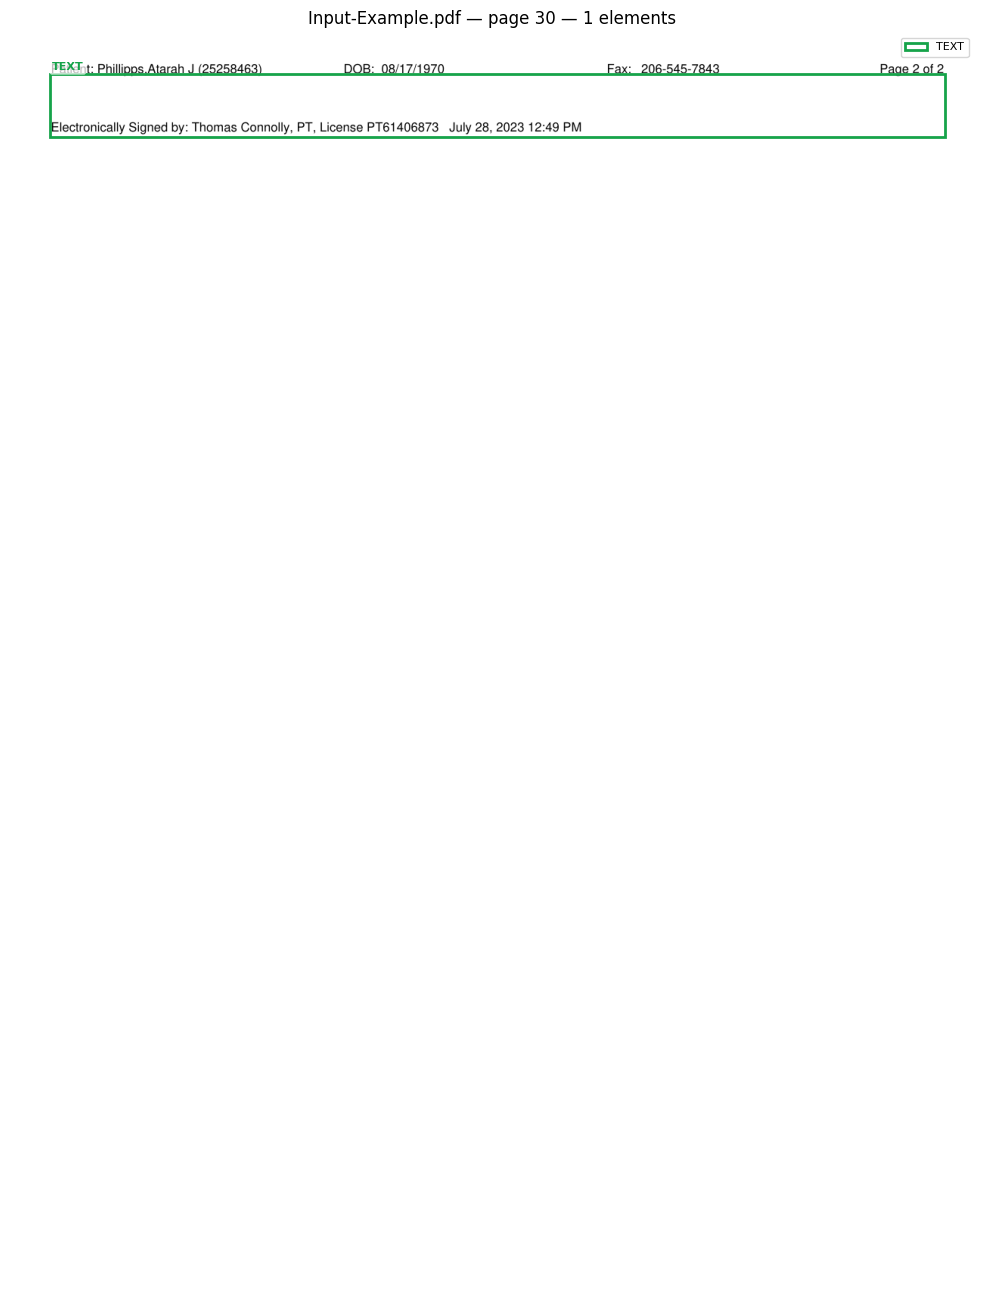

Saved: /home/dev/Projects/kwikee/medrecs_2/data/outputs/visualizations/page_30_bboxes.png


In [1]:
import io
import json
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

# --- paths (no other notebook variables) ---
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

STRUCTURED_JSON = ROOT / "data" / "outputs" / "structured_document.json"
PDF_PATH = ROOT / "data" / "input" / "Input-Example.pdf"
PAGE_NUMBER = 30   # 1–30 for your current JSON
DPI = 150

TYPE_COLORS = {
    "HEADER": "#2563eb",
    "TEXT": "#16a34a",
    "TABLE": "#ea580c",
    "IMAGE": "#9333ea",
    "CHECKBOX": "#ca8a04",
    "SIGNATURE": "#dc2626",
    "BARCODE": "#0891b2",
    "FOOTER": "#64748b",
}

# Load JSON
structured = json.loads(STRUCTURED_JSON.read_text(encoding="utf-8"))
page_elements = [
    element
    for element in structured["elements"]
    if element.get("page_number") == PAGE_NUMBER
]

# Render PDF page as image
if not PDF_PATH.exists():
    raise FileNotFoundError(f"PDF not found: {PDF_PATH}")

pdf_document = fitz.open(PDF_PATH)
try:
    if PAGE_NUMBER < 1 or PAGE_NUMBER > len(pdf_document):
        raise ValueError(f"PAGE_NUMBER {PAGE_NUMBER} out of range (1–{len(pdf_document)})")
    pixmap = pdf_document[PAGE_NUMBER - 1].get_pixmap(
        matrix=fitz.Matrix(DPI / 72, DPI / 72),
        alpha=False,
    )
finally:
    pdf_document.close()

page_image = Image.open(io.BytesIO(pixmap.tobytes("png")))
image_width, image_height = page_image.size

# Draw boxes on PDF image
figure, axes = plt.subplots(1, 1, figsize=(10, 13))
axes.imshow(page_image)
axes.set_xlim(0, image_width)
axes.set_ylim(image_height, 0)
axes.axis("off")

legend_handles = {}
for element in page_elements:
    bounding_boxes = element.get("bounding_boxes") or []
    if not bounding_boxes:
        continue

    element_type = element.get("element_type", "TEXT")
    color = TYPE_COLORS.get(element_type, "#ef4444")
    x0, y0, x1, y1 = bounding_boxes[0]

    axes.add_patch(
        Rectangle(
            (x0 * image_width, y0 * image_height),
            (x1 - x0) * image_width,
            (y1 - y0) * image_height,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
    )
    axes.text(
        x0 * image_width + 2,
        max(y0 * image_height - 4, 8),
        element_type,
        color=color,
        fontsize=8,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"),
    )
    if element_type not in legend_handles:
        legend_handles[element_type] = Rectangle(
            (0, 0), 1, 1, facecolor="none", edgecolor=color, linewidth=2
        )

axes.set_title(
    f"{PDF_PATH.name} — page {PAGE_NUMBER} — {len(page_elements)} elements",
    fontsize=12,
)
if legend_handles:
    axes.legend(legend_handles.values(), legend_handles.keys(), loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

# Optional: save overlay
output_path = ROOT / "data" / "outputs" / "visualizations" / f"page_{PAGE_NUMBER:02d}_bboxes.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Saved: {output_path}")

In [ ]:
# Export all extracted pages
for pn in range(1, doc_data["total_pages"] + 1):
    els = elements_for_page(doc_data, pn)
    fig, _ = visualize_page(VIZ_PDF, pn, els, dpi=VIZ_DPI, show_labels=True, figsize=(10, 13))
    path = VIZ_OUT_DIR / f"page_{pn:02d}_bboxes.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved page {pn}: {len(els)} boxes → {path}")

print(f"\nAll images in: {VIZ_OUT_DIR}")

Saved page 1: 11 boxes → /home/dev/Projects/kwikee/medrecs_2/data/outputs/visualizations/page_01_bboxes.png
Saved page 2: 10 boxes → /home/dev/Projects/kwikee/medrecs_2/data/outputs/visualizations/page_02_bboxes.png
Saved page 3: 13 boxes → /home/dev/Projects/kwikee/medrecs_2/data/outputs/visualizations/page_03_bboxes.png
Saved page 4: 11 boxes → /home/dev/Projects/kwikee/medrecs_2/data/outputs/visualizations/page_04_bboxes.png

All images in: /home/dev/Projects/kwikee/medrecs_2/data/outputs/visualizations


IntSlider(value=1, continuous_update=False, description='Page:', max=4, min=1)

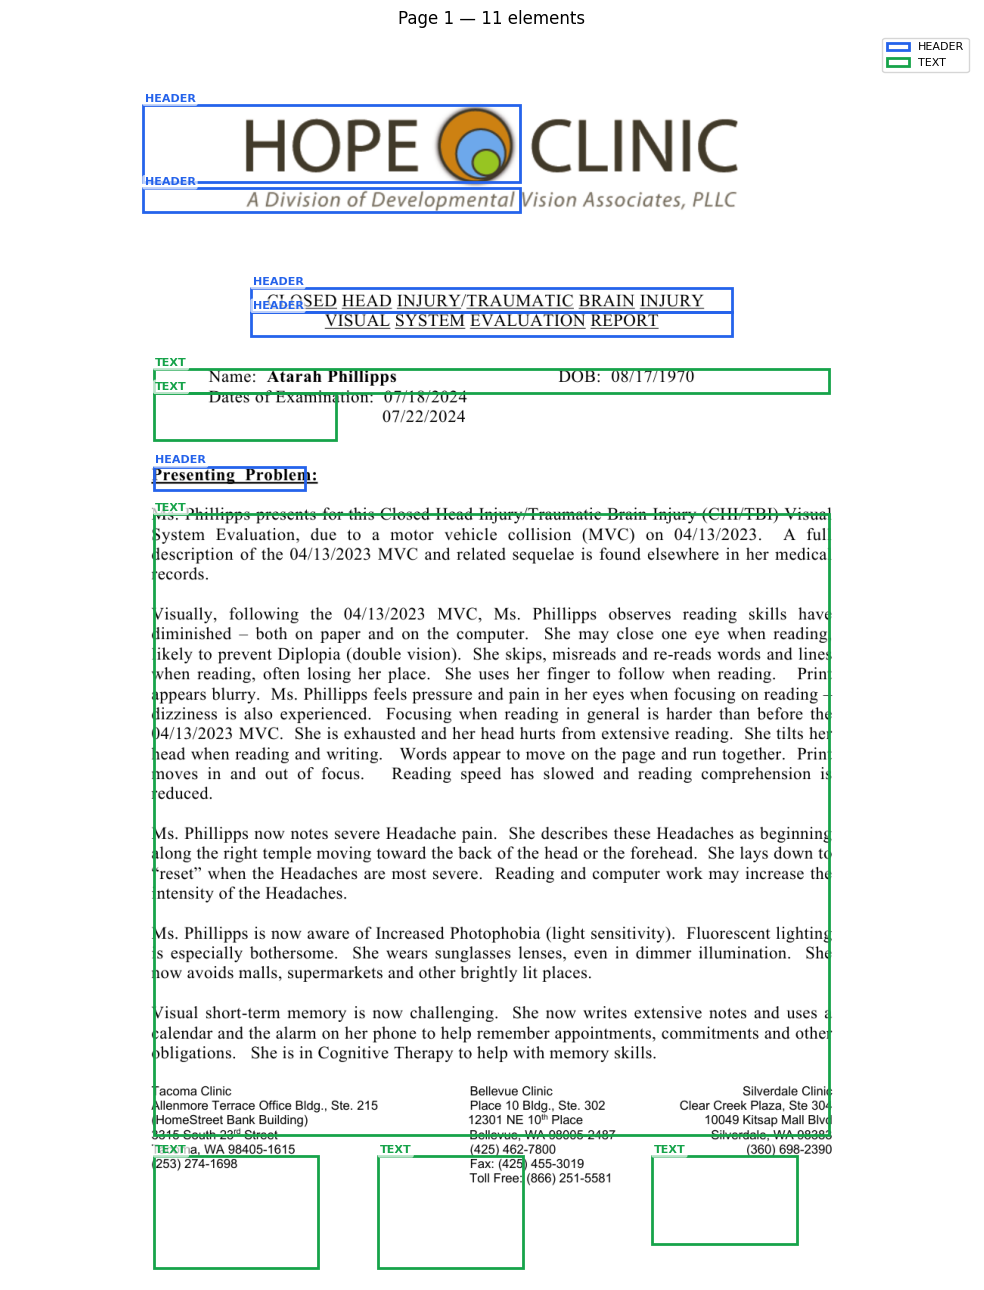

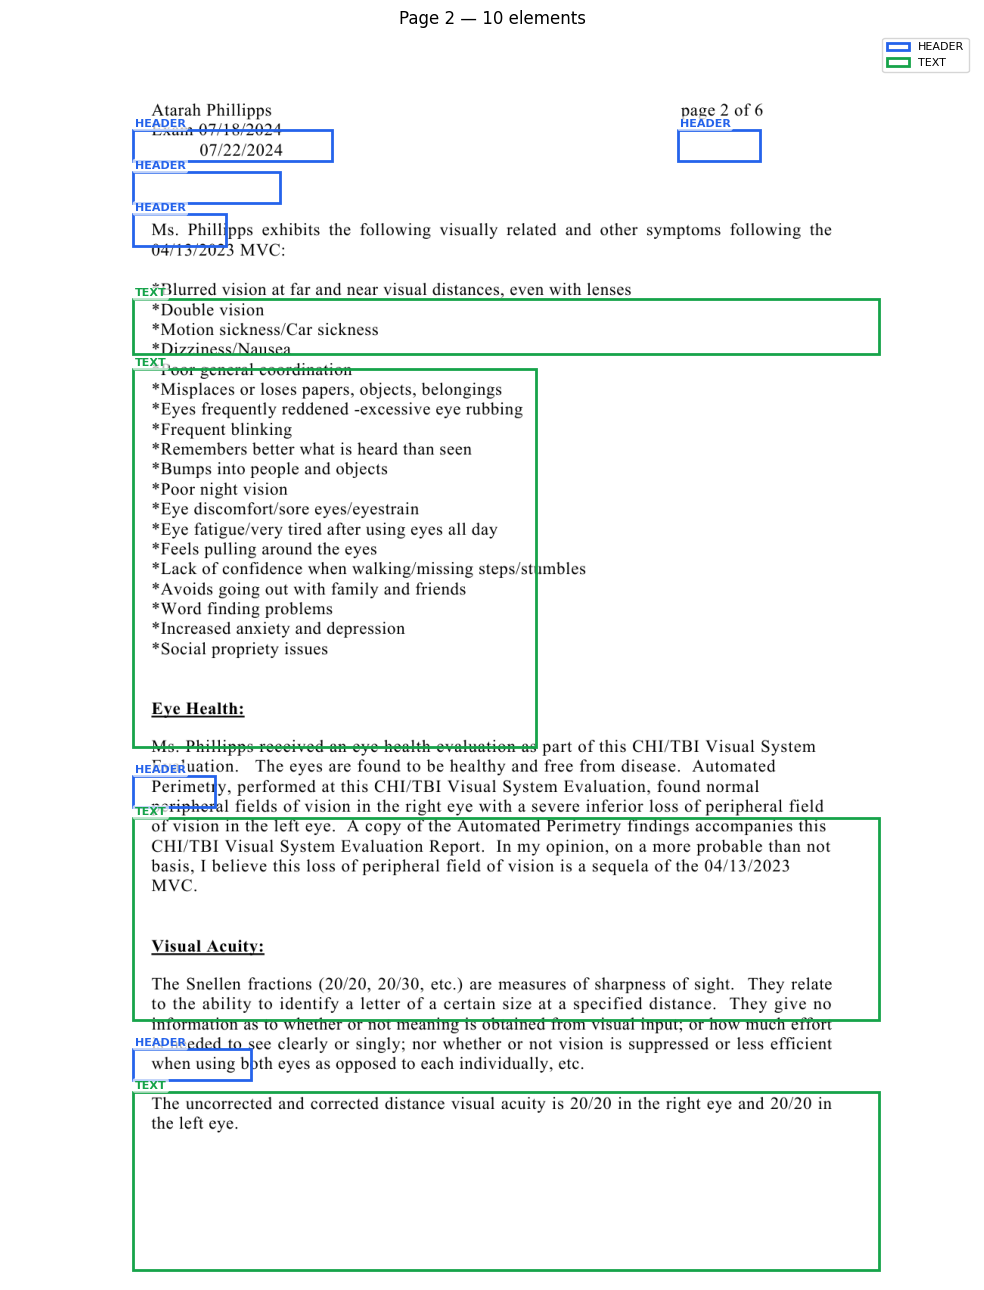

In [ ]:
# Optional: interactive page slider (requires ipywidgets)
try:
    import ipywidgets as widgets
    from IPython.display import display

    def _on_page_change(change):
        pn = change["new"]
        els = elements_for_page(doc_data, pn)
        fig, _ = visualize_page(VIZ_PDF, pn, els, dpi=VIZ_DPI)
        plt.show()

    slider = widgets.IntSlider(
        value=1,
        min=1,
        max=doc_data["total_pages"],
        step=1,
        description="Page:",
        continuous_update=False,
    )
    slider.observe(_on_page_change, names="value")
    display(slider)
    _on_page_change({"new": 1})
except ImportError:
    print("Install ipywidgets for interactive slider: pip install ipywidgets")

Page 1: 11 elements


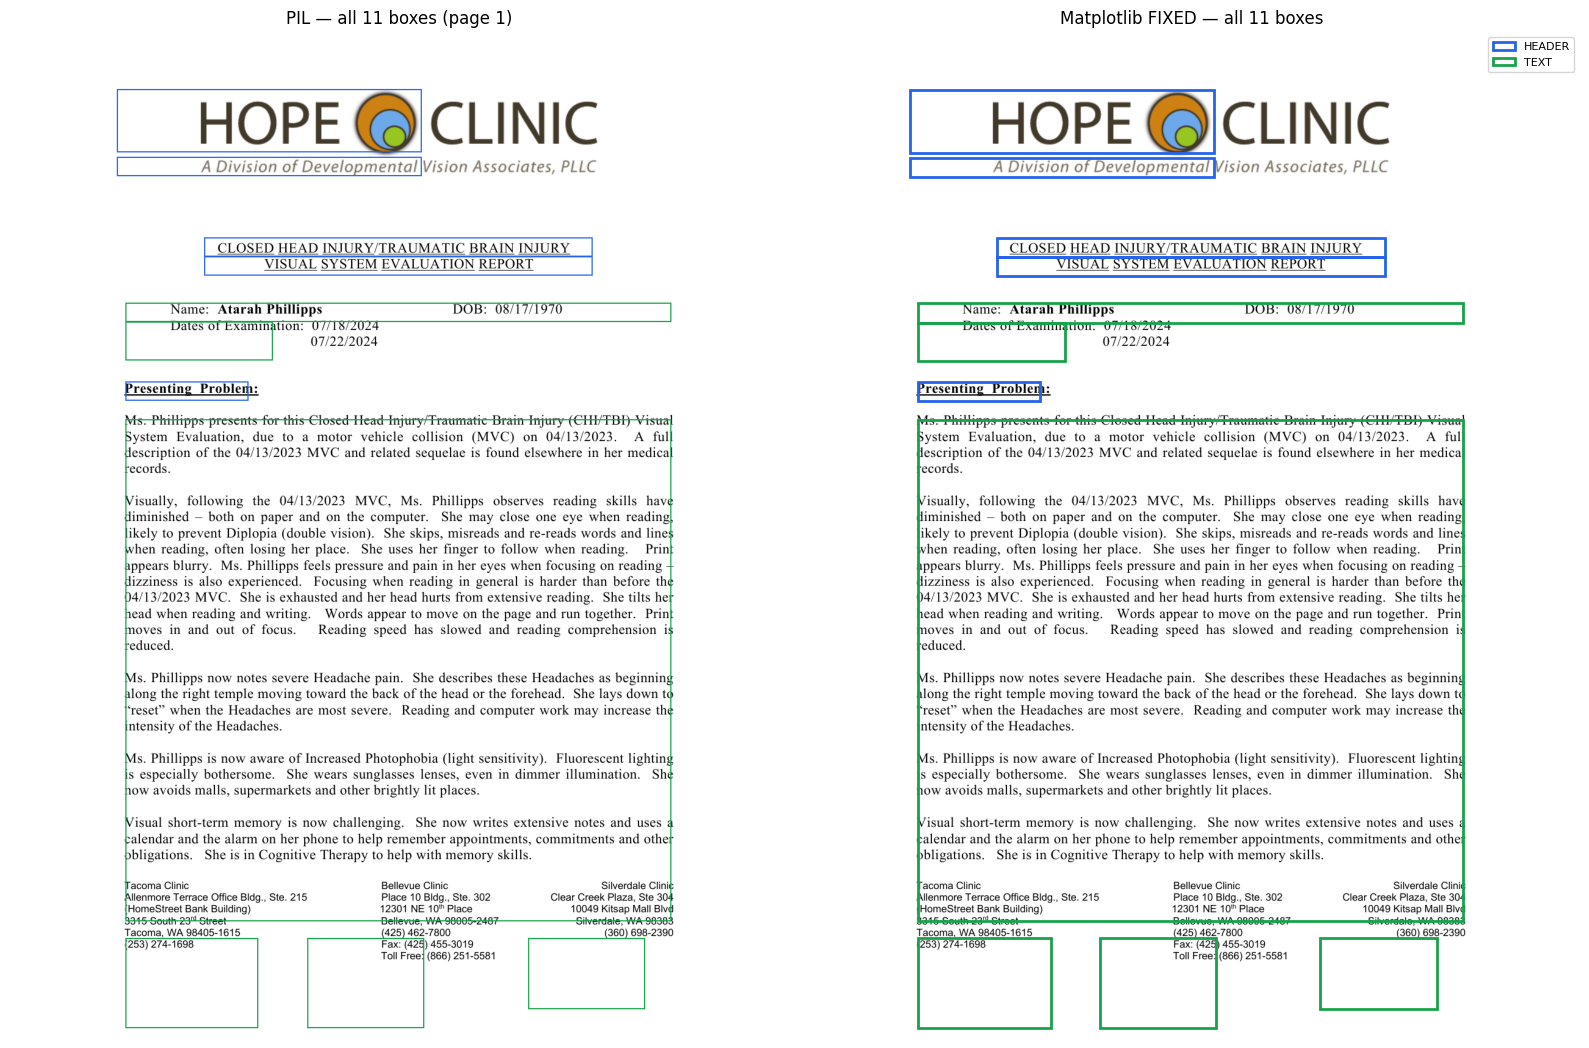

Saved → /home/dev/Projects/kwikee/medrecs_2/data/outputs/visualizations/page_01_all_boxes_test.png


In [8]:
import io
import json
from pathlib import Path

import fitz
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image, ImageDraw

# --- config ---
STRUCTURED_JSON = ROOT / "data/outputs/structured_document.json"
PAGE_TO_VIEW = 1          # change 1–4
DPI_VIZ = DPI             # same as extraction (150)

TYPE_COLORS = {
    "HEADER": "#2563eb",
    "TEXT": "#16a34a",
    "TABLE": "#ea580c",
    "IMAGE": "#9333ea",
    "CHECKBOX": "#ca8a04",
    "SIGNATURE": "#dc2626",
    "BARCODE": "#0891b2",
    "FOOTER": "#64748b",
}

def render_page(pdf_path: Path, page_number: int, dpi: int) -> Image.Image:
    doc = fitz.open(pdf_path)
    try:
        page = doc[page_number - 1]
        pix = page.get_pixmap(matrix=fitz.Matrix(dpi / 72, dpi / 72), alpha=False)
        return Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    finally:
        doc.close()

doc_data = json.loads(STRUCTURED_JSON.read_text(encoding="utf-8"))
elements = [e for e in doc_data["elements"] if e["page_number"] == PAGE_TO_VIEW]
print(f"Page {PAGE_TO_VIEW}: {len(elements)} elements")

img = render_page(PDF_PATH, PAGE_TO_VIEW, DPI_VIZ)
w, h = img.size

# --- A) PIL: all boxes (pixel-perfect reference) ---
pil_overlay = img.copy()
draw = ImageDraw.Draw(pil_overlay)
for el in elements:
    boxes = el.get("bounding_boxes") or []
    if not boxes:
        continue
    x0, y0, x1, y1 = boxes[0]
    color = TYPE_COLORS.get(el["element_type"], "#ef4444")
    draw.rectangle(
        [int(x0 * w), int(y0 * h), int(x1 * w), int(y1 * h)],
        outline=color,
        width=2,
    )

# --- B) Matplotlib FIXED: all boxes ---
fig, axes = plt.subplots(1, 2, figsize=(16, 13))

# left = PIL reference
axes[0].imshow(pil_overlay, extent=[0, w, h, 0], origin="upper")
axes[0].set_xlim(0, w)
axes[0].set_ylim(h, 0)
axes[0].set_aspect("equal")
axes[0].set_title(f"PIL — all {len(elements)} boxes (page {PAGE_TO_VIEW})")
axes[0].axis("off")

# right = matplotlib patches (fixed extent)
axes[1].imshow(img, extent=[0, w, h, 0], origin="upper")
axes[1].set_xlim(0, w)
axes[1].set_ylim(h, 0)
axes[1].set_aspect("equal")

legend = {}
for el in elements:
    boxes = el.get("bounding_boxes") or []
    if not boxes:
        continue
    et = el.get("element_type", "TEXT")
    color = TYPE_COLORS.get(et, "#ef4444")
    x0, y0, x1, y1 = boxes[0]
    axes[1].add_patch(
        Rectangle(
            (x0 * w, y0 * h),
            (x1 - x0) * w,
            (y1 - y0) * h,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
    )
    if et not in legend:
        legend[et] = Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=color, linewidth=2)

if legend:
    axes[1].legend(legend.values(), legend.keys(), loc="upper right", fontsize=8)
axes[1].set_title(f"Matplotlib FIXED — all {len(elements)} boxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# --- optional: save ---
out = ROOT / "data/outputs/visualizations" / f"page_{PAGE_TO_VIEW:02d}_all_boxes_test.png"
pil_overlay.save(out)
print(f"Saved → {out}")